# Inspect ICARUS VAE / CAE training

**Kernel:** `conda env:.conda-diffusion` on EAF (`jupyter-munjung`).

Fresh replacement for `03b_LearningCurves_ICARUS.ipynb` (use this one).

Reads:
- `/scratch/7DayLifetime/munjung/anomaly-detection/training/{vae,cae}/icarus/`
- durable mirror under `/exp/sbnd/data/users/munjung/anomaly-detection/training/{vae,cae}/icarus/`

Also writes `DATA_ROOT/training/ae_icarus_status.json` for Cursor/sbndbuild.

Ends with a **same-patch** VAE / CAE / DDIM comparison on **GPU** (set `USE_GPU=False` for CPU).


In [10]:
from __future__ import annotations

import csv
import json
import socket
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_ROOT = Path("/exp/sbnd/data/users/munjung/anomaly-detection")
SCRATCH = Path("/scratch/7DayLifetime/munjung/anomaly-detection/training")
CURVES = DATA_ROOT / "training" / "curves" / "icarus"
STATUS = DATA_ROOT / "training" / "ae_icarus_status.json"
CURVES.mkdir(parents=True, exist_ok=True)

AES = ("vae", "cae")
print("hostname:", socket.gethostname())
print("scratch exists:", SCRATCH.is_dir(), SCRATCH)


hostname: jupyter-munjung
scratch exists: True /scratch/7DayLifetime/munjung/anomaly-detection/training


In [11]:
def log_dirs(ae: str) -> list[Path]:
    return [SCRATCH / ae / "icarus", DATA_ROOT / "training" / ae / "icarus"]


def best_progress(ae: str) -> Path | None:
    for d in log_dirs(ae):
        p = d / "progress.csv"
        if p.is_file():
            return p
    return None


def load_csv(path: Path) -> list[dict]:
    with path.open() as fh:
        return list(csv.DictReader(fh))


def fnum(row: dict, *keys: str) -> float | None:
    for k in keys:
        v = row.get(k)
        if v not in (None, ""):
            try:
                return float(v)
            except ValueError:
                pass
    return None


status = {
    "hostname": socket.gethostname(),
    "utc": datetime.now(timezone.utc).isoformat(),
    "models": {},
}
series = {}

for ae in AES:
    info = {"dirs": {}, "progress": None}
    for d in log_dirs(ae):
        exists = d.is_dir()
        pts = sorted(d.glob("*.pt")) if exists else []
        info["dirs"][str(d)] = {
            "exists": exists,
            "n_pt": len(pts),
            "latest_pt": pts[-1].name if pts else None,
        }
        print(f"{ae} {d}: exists={exists} n_pt={len(pts)} latest={pts[-1].name if pts else None}")

    prog = best_progress(ae)
    if prog is None:
        print(f"{ae}: no progress.csv yet")
        status["models"][ae] = info
        continue

    rows = load_csv(prog)
    info["progress"] = str(prog)
    info["n_rows"] = len(rows)
    if not rows:
        status["models"][ae] = info
        continue

    steps, loss, vloss = [], [], []
    for r in rows:
        s = fnum(r, "step", "steps")
        y = fnum(r, "loss", "mse", "l2")
        v = fnum(r, "val-loss_q0", "val-mse_q0", "val-l2_q0")
        if s is None or y is None:
            continue
        steps.append(s)
        loss.append(y)
        vloss.append(v)

    last = rows[-1]
    info.update(
        {
            "last_step": last.get("step") or last.get("steps"),
            "loss": last.get("loss") or last.get("mse") or last.get("l2"),
            "val_loss": last.get("val-loss_q0") or last.get("val-mse_q0") or last.get("val-l2_q0"),
            "kld": last.get("kld") or last.get("val-kld_q0"),
            "loss_first": loss[0] if loss else None,
            "loss_last": loss[-1] if loss else None,
        }
    )
    series[ae] = (np.asarray(steps), np.asarray(loss), np.asarray(vloss, dtype=object))
    print(
        f"{ae}: rows={len(rows)} last_step={info['last_step']} "
        f"loss={info['loss']} val={info['val_loss']}  <- {prog}"
    )
    status["models"][ae] = info

STATUS.parent.mkdir(parents=True, exist_ok=True)
STATUS.write_text(json.dumps(status, indent=2))
print("wrote", STATUS)


vae /scratch/7DayLifetime/munjung/anomaly-detection/training/vae/icarus: exists=True n_pt=90 latest=optbrats2update030000.pt
vae /exp/sbnd/data/users/munjung/anomaly-detection/training/vae/icarus: exists=True n_pt=0 latest=None
vae: rows=608 last_step=30350 loss=0.004511759036298224 val=0.0045245336  <- /scratch/7DayLifetime/munjung/anomaly-detection/training/vae/icarus/progress.csv
cae /scratch/7DayLifetime/munjung/anomaly-detection/training/cae/icarus: exists=True n_pt=105 latest=optbrats2update035000.pt
cae /exp/sbnd/data/users/munjung/anomaly-detection/training/cae/icarus: exists=True n_pt=0 latest=None
cae: rows=711 last_step=35500 loss=0.00459452395249779 val=0.0046435534  <- /scratch/7DayLifetime/munjung/anomaly-detection/training/cae/icarus/progress.csv
wrote /exp/sbnd/data/users/munjung/anomaly-detection/training/ae_icarus_status.json


saved /exp/sbnd/data/users/munjung/anomaly-detection/training/curves/icarus/icarus_ae_loss_live.pdf


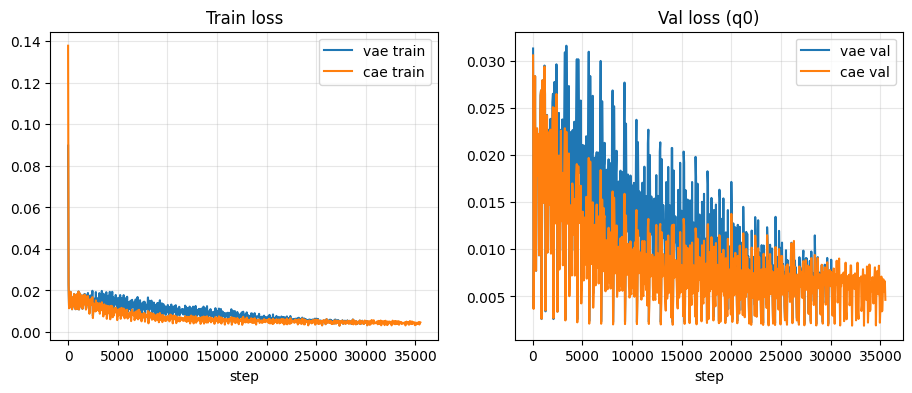

In [12]:
# Loss curves
if not series:
    print("No progress yet — re-run after training has written progress.csv")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ae, (steps, loss, vloss) in series.items():
        axes[0].plot(steps, loss, label=f"{ae} train")
        vv = [(s, v) for s, v in zip(steps, vloss) if v is not None]
        if vv:
            axes[1].plot([s for s, _ in vv], [v for _, v in vv], label=f"{ae} val")
    axes[0].set_title("Train loss")
    axes[1].set_title("Val loss (q0)")
    for ax in axes:
        ax.set_xlabel("step")
        ax.legend()
        ax.grid(True, alpha=0.3)
    out = CURVES / "icarus_ae_loss_live.pdf"
    fig.savefig(out, bbox_inches="tight")
    print("saved", out)
    plt.show()


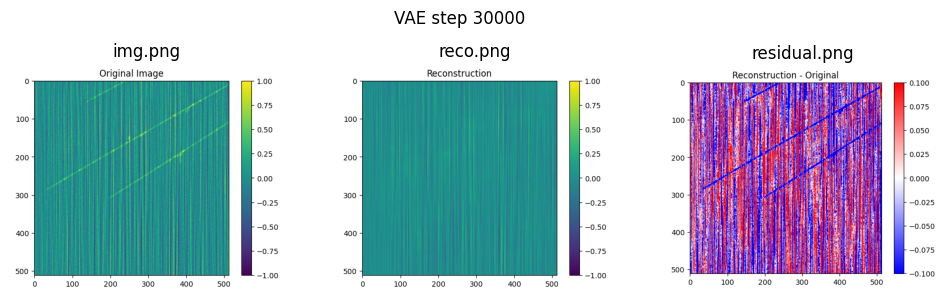

vae from /scratch/7DayLifetime/munjung/anomaly-detection/training/vae/icarus/validation-plots/step-30000-ae/img-0


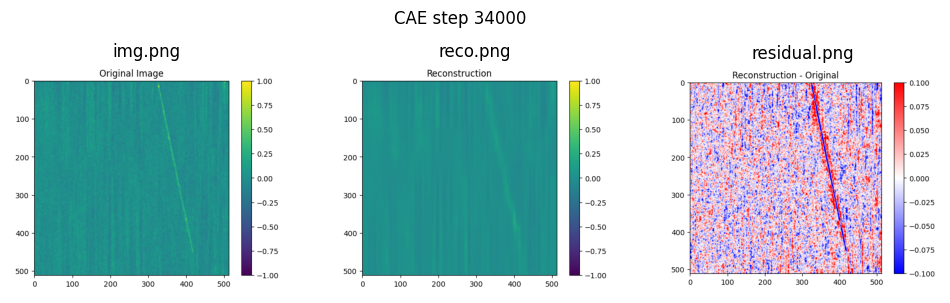

cae from /scratch/7DayLifetime/munjung/anomaly-detection/training/cae/icarus/validation-plots/step-34000-ae/img-0


In [14]:
# AE validation-plot thumbnails (latest step)
import matplotlib.image as mpimg

IMG_IDX = 0
for ae in AES:
    shown = False
    for root in log_dirs(ae):
        vp = root / "validation-plots"
        if not vp.is_dir():
            continue
        steps = sorted(
            int(p.name.split("-")[1])
            for p in vp.glob("step-*-ae")
            if p.name.startswith("step-")
        )
        if not steps:
            continue
        step = steps[-1]
        d = vp / f"step-{step}-ae" / f"img-{IMG_IDX}"
        files = [d / n for n in ("img.png", "reco.png", "residual.png") if (d / n).is_file()]
        if not files:
            continue
        fig, axes = plt.subplots(1, len(files), figsize=(4 * len(files), 3.5))
        if len(files) == 1:
            axes = [axes]
        fig.suptitle(f"{ae.upper()} step {step}")
        for ax, path in zip(axes, files):
            ax.imshow(mpimg.imread(path))
            ax.set_title(path.name)
            ax.axis("off")
        plt.show()
        print(ae, "from", d)
        shown = True
        break
    if not shown:
        print(ae, ": no validation-plots yet")


## Same-patch VAE / CAE / DDIM (GPU default)

**Workflow**
1. **Load tiles** — pick a **plane-1** H5 (set `PLANE` / `H5_INDEX`) and preprocess like training.
2. **Browse** — scan a page of thumbnails; note the index you want.
3. **Choose** — set `PATCH_IDX` and preview that tile.
4. **Run models** — reconstruct with latest AE EMAs **and** archived ICARUS diffusion (`ddim2ddim`) on **GPU** (set `USE_GPU=False` for CPU).

Re-run browse/choose as needed before the run cell. Diffusion at `DIFF_T=200` is slow on GPU by default — lower `DIFF_T` for a quicker look.


In [ ]:
# 1) Load tiles (same preprocessing as training)
import re
import sys

import torch as th

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
DIFFUSION_ROOT = APP_ROOT / "train" / "diffusion-anomaly"
for p in (APP_ROOT, APP_ROOT / "_stubs", DIFFUSION_ROOT, APP_ROOT / "inference"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from configs.paths import DATA_ROOT, DEFAULT_T, GPUTNAM_DNN_ROI, ae_model_config
from guided_diffusion.image_datasets import load_image_file
from guided_diffusion.script_util import create_autoencoder
from guided_diffusion import dist_util
from run_ddim2ddim_inference import build_model_and_diffusion, ddim2ddim_reconstruct

# Device: default GPU when available. Set USE_GPU=False to force CPU.
USE_GPU = True
DEVICE = th.device("cuda" if USE_GPU and th.cuda.is_available() else "cpu")
if USE_GPU and DEVICE.type != "cuda":
    print("WARNING: USE_GPU=True but CUDA unavailable; falling back to CPU")
print(f"DEVICE={DEVICE}  cuda_available={th.cuda.is_available()}")

# ICARUS diffusion (archived nominal best); override if needed
DIFF_CKPT = DATA_ROOT / "archive" / "ICARUS_NNs" / "nominal_best.pt"
DIFF_T = int(DEFAULT_T)  # ddim2ddim timestep (200 default; lower is faster on CPU)
DIFF_OVERRIDES = {}  # e.g. {"noise_schedule": "cosine"} for non-linear archives

DNN_ROI = GPUTNAM_DNN_ROI
assert DNN_ROI.is_dir(), DNN_ROI
IMAGE_SIZE = 512

# --- pick plane / file (filenames look like …-tpcN-planeM.h5) ---
PLANE = 1  # 0 or 1 in this DNN-ROI set
H5_FILES = sorted(p for p in DNN_ROI.glob("*.h5") if f"-plane{PLANE}." in p.name)
assert H5_FILES, f"No *-plane{PLANE}.h5 under {DNN_ROI}"
H5_INDEX = 0  # index within the plane-filtered list
H5_PATH = H5_FILES[H5_INDEX]
assert H5_PATH.is_file(), H5_PATH

print(f"plane={PLANE}  h5 files available: {len(H5_FILES)}")
print(f"loading [{H5_INDEX}] {H5_PATH.name} …")
TILES, _ = load_image_file(str(H5_PATH), IMAGE_SIZE)  # (N, 1, H, W) in [-1, 1]
TILE_ABSMAX = np.array([float(np.max(np.abs(t))) for t in TILES])
CHARGED = np.where(TILE_ABSMAX >= 0.2)[0]
print(f"tiles={len(TILES)}  charged(>=0.2)={len(CHARGED)}  absmax range=[{TILE_ABSMAX.min():.3f}, {TILE_ABSMAX.max():.3f}]")


def ema_step(path: Path) -> int:
    m = re.search(r"_(\d+)\.pt$", path.name)
    return int(m.group(1)) if m else -1


def latest_ema(ae: str) -> Path | None:
    best: Path | None = None
    best_s = -1
    for d in log_dirs(ae):
        if not d.is_dir():
            continue
        for p in list(d.glob("emabrats2update_*.pt")) + list(d.glob("ema_*.pt")):
            s = ema_step(p)
            if s > best_s:
                best_s, best = s, p
    return best


def load_ae(ae: str, ckpt: Path):
    cfg = ae_model_config(ae)
    model = create_autoencoder(**cfg)
    state = th.load(ckpt, map_location="cpu", weights_only=True)
    model.load_state_dict(state)
    model.to(DEVICE).eval()
    return model


_DIFF_CACHE: dict = {}


def load_diffusion(ckpt: Path, overrides: dict | None = None):
    key = (str(ckpt), tuple(sorted((overrides or {}).items())))
    if _DIFF_CACHE.get("key") == key:
        return _DIFF_CACHE["model"], _DIFF_CACHE["diffusion"]
    model, diffusion = build_model_and_diffusion(overrides)
    sd = dist_util.load_state_dict(str(ckpt), map_location="cpu")
    model.load_state_dict(sd)
    model.to(DEVICE).eval()
    _DIFF_CACHE.update({"key": key, "model": model, "diffusion": diffusion})
    return model, diffusion


page 0/5  showing 16/85 (charged indices)  file=82090893_9-bnb-nom-tpc0-plane1.h5
indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


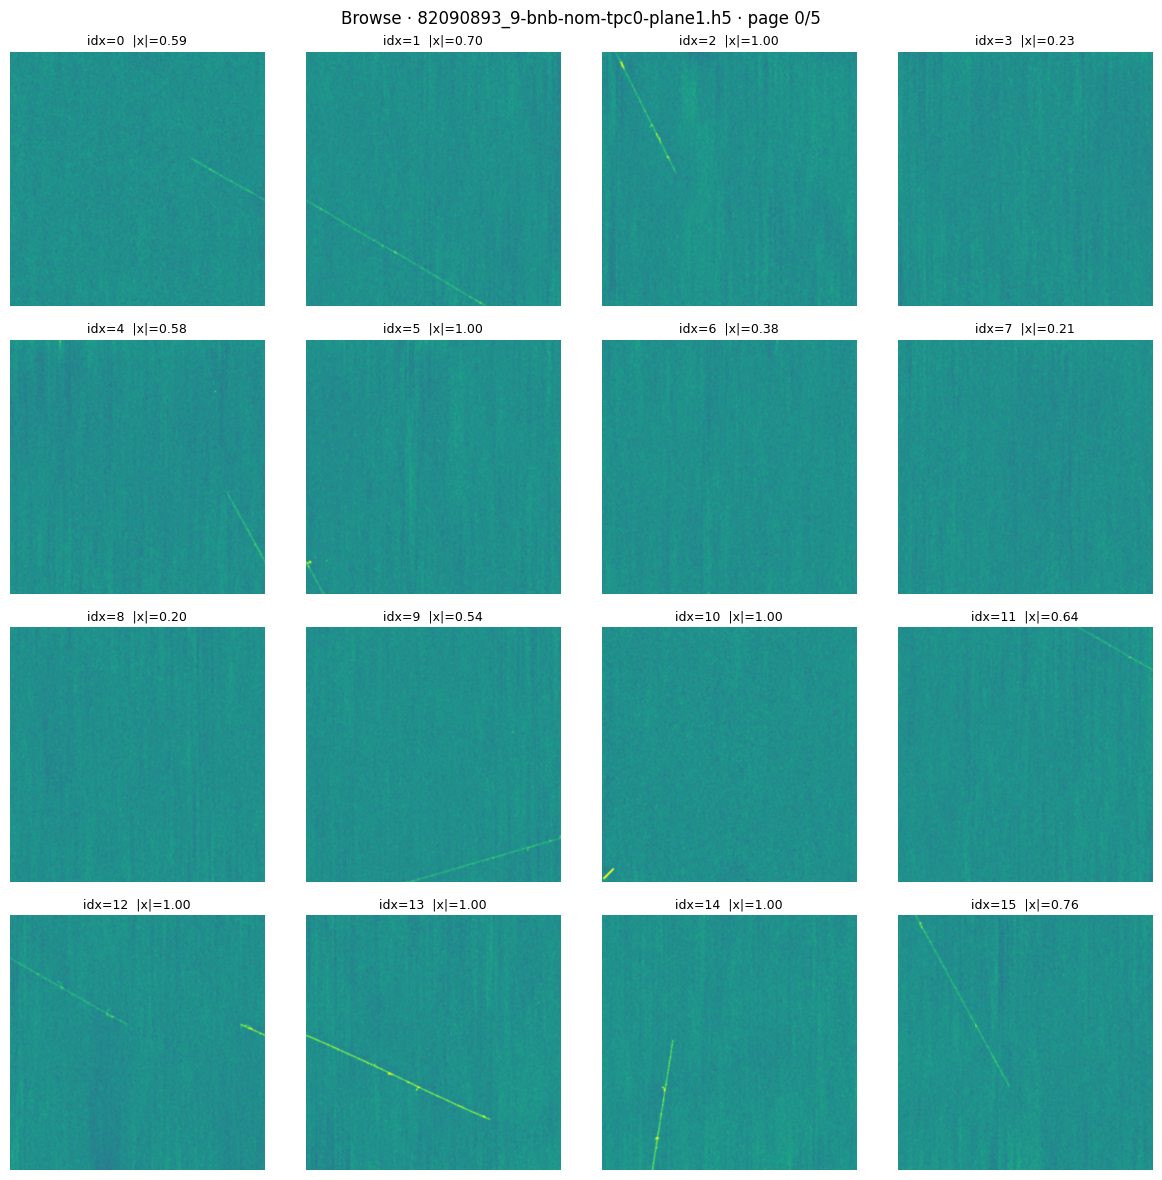

In [21]:
# 2) Browse tiles — bump PAGE to scan; set CHARGED_ONLY=True to skip empties
PAGE = 0          # 0-based page of thumbnails
N_PER_PAGE = 16   # thumbnails per page
NCOLS = 4
CHARGED_ONLY = True

pool = CHARGED if CHARGED_ONLY else np.arange(len(TILES))
if len(pool) == 0:
    raise RuntimeError("No tiles to browse (CHARGED_ONLY emptied the pool?)")

n_pages = max(1, int(np.ceil(len(pool) / N_PER_PAGE)))
PAGE = int(np.clip(PAGE, 0, n_pages - 1))
sl = pool[PAGE * N_PER_PAGE : (PAGE + 1) * N_PER_PAGE]
print(f"page {PAGE}/{n_pages - 1}  showing {len(sl)}/{len(pool)} "
      f"({'charged' if CHARGED_ONLY else 'all'} indices)  file={H5_PATH.name}")
print("indices:", list(map(int, sl)))

nrows = int(np.ceil(len(sl) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(3.0 * NCOLS, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, idx in zip(axes, sl):
    ax.imshow(np.squeeze(TILES[idx]), vmin=-1, vmax=1)
    ax.set_title(f"idx={int(idx)}  |x|={TILE_ABSMAX[idx]:.2f}", fontsize=9)
    ax.axis("off")
for ax in axes[len(sl):]:
    ax.axis("off")
fig.suptitle(f"Browse · {H5_PATH.name} · page {PAGE}/{n_pages - 1}")
plt.tight_layout()
plt.show()


PATCH_IDX=13  absmax=1.000  shape=(1, 512, 512)  file=82090893_9-bnb-nom-tpc0-plane1.h5


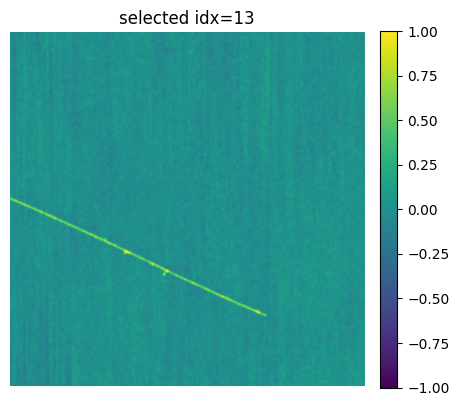

In [26]:
# 3) Choose patch — set PATCH_IDX from the browse grid, then run this cell
# PATCH_IDX = int(CHARGED[0]) if len(CHARGED) else 0  # <-- change me after browsing
PATCH_IDX = 13

assert 0 <= PATCH_IDX < len(TILES), (PATCH_IDX, len(TILES))
PATCH = TILES[PATCH_IDX]
print(f"PATCH_IDX={PATCH_IDX}  absmax={TILE_ABSMAX[PATCH_IDX]:.3f}  shape={PATCH.shape}  file={H5_PATH.name}")

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.squeeze(PATCH), vmin=-1, vmax=1)
ax.set_title(f"selected idx={PATCH_IDX}")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


In [ ]:
# 4) Run VAE + CAE + DDIM on the chosen patch
assert "PATCH" in dir() and "PATCH_IDX" in dir(), "Run the Choose cell first"
ckpts = {ae: latest_ema(ae) for ae in AES}
for ae, ckpt in ckpts.items():
    print(f"{ae}: ckpt={ckpt}")
missing = [ae for ae, c in ckpts.items() if c is None]
if missing:
    raise FileNotFoundError(f"Missing EMA for {missing} under scratch/durable icarus dirs")
assert DIFF_CKPT.is_file(), DIFF_CKPT
print(f"ddim: ckpt={DIFF_CKPT}  T={DIFF_T}  device={DEVICE}")

x = th.from_numpy(PATCH.astype(np.float32)).unsqueeze(0).to(DEVICE)  # (1,1,H,W)
recos: dict[str, np.ndarray] = {}
mses: dict[str, float] = {}
with th.no_grad():
    for ae in AES:
        model = load_ae(ae, ckpts[ae])
        reco = model.reconstruct(x).cpu().numpy()[0]
        recos[ae] = reco
        mses[ae] = float(np.mean((reco - PATCH) ** 2))
        del model
        print(f"{ae}: mse={mses[ae]:.6g}  ckpt_step={ema_step(ckpts[ae])}")

    dmodel, diffusion = load_diffusion(DIFF_CKPT, DIFF_OVERRIDES)
    _, dreco = ddim2ddim_reconstruct(diffusion, dmodel, x, DIFF_T, progress=True)
    recos["ddim"] = dreco.cpu().numpy()[0]
    mses["ddim"] = float(np.mean((recos["ddim"] - PATCH) ** 2))
    print(f"ddim: mse={mses['ddim']:.6g}  T={DIFF_T}")

SHOW_SUPTITLE = False  # metadata goes to the log file by default

info = (
    f"Same tile · {H5_PATH.name} · idx={PATCH_IDX} · "
    f"VAE@{ema_step(ckpts['vae'])} CAE@{ema_step(ckpts['cae'])} "
    f"DDIM@{DIFF_CKPT.name}/T{DIFF_T} · device={DEVICE} · "
    f"mse_vae={mses['vae']:.6g} mse_cae={mses['cae']:.6g} mse_ddim={mses['ddim']:.6g}"
)

# Layout: Input spans both rows (left); VAE | CAE | This work (reco / reco-input);
# one shared colorbar per row; row labels on the right edge.
COL_LABELS = ("VAE", "CAE", "This work")
COL_KEYS = ("vae", "cae", "ddim")
RECO_CLIM = (-1.0, 1.0)
RES_CLIM = (-0.1, 0.1)

fig = plt.figure(figsize=(13.5, 6.2))
outer = fig.add_gridspec(1, 2, width_ratios=[1.15, 3.4], wspace=0.18)
# Center Input vertically between the two model rows (same panel size, not stretched).
left = outer[0, 0].subgridspec(3, 1, height_ratios=[0.5, 1.0, 0.5], hspace=0.0)
for r in (0, 2):
    ax_pad = fig.add_subplot(left[r, 0])
    ax_pad.axis("off")
ax_in = fig.add_subplot(left[1, 0])
im_in = ax_in.imshow(np.squeeze(PATCH), cmap="viridis", vmin=RECO_CLIM[0], vmax=RECO_CLIM[1])
ax_in.set_title("Input")
ax_in.axis("off")

right = outer[0, 1].subgridspec(
    2, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.06, hspace=0.10
)
ims_reco, ims_res = [], []
axes_reco, axes_res = [], []
for i, (lab, key) in enumerate(zip(COL_LABELS, COL_KEYS)):
    ax_t = fig.add_subplot(right[0, i])
    ax_b = fig.add_subplot(right[1, i])
    im_t = ax_t.imshow(
        np.squeeze(recos[key]), cmap="viridis", vmin=RECO_CLIM[0], vmax=RECO_CLIM[1]
    )
    im_b = ax_b.imshow(
        np.squeeze(recos[key] - PATCH), cmap="bwr", vmin=RES_CLIM[0], vmax=RES_CLIM[1]
    )
    ax_t.set_title(lab)
    ax_t.axis("off")
    ax_b.axis("off")
    axes_reco.append(ax_t)
    axes_res.append(ax_b)
    ims_reco.append(im_t)
    ims_res.append(im_b)

cax_t = fig.add_subplot(right[0, 3])
cax_b = fig.add_subplot(right[1, 3])
fig.colorbar(ims_reco[0], cax=cax_t)
fig.colorbar(ims_res[0], cax=cax_b)

# Row labels along the right edge (rotated to follow the edge)
fig.text(0.965, 0.70, "Reco.", rotation=270, va="center", ha="center", fontsize=11)
fig.text(0.965, 0.30, "Reco. - Input", rotation=270, va="center", ha="center", fontsize=11)

if SHOW_SUPTITLE:
    fig.suptitle(info)
    fig.subplots_adjust(top=0.88)

stem = re.sub(r"[^A-Za-z0-9._-]+", "_", H5_PATH.stem)
out = CURVES / f"icarus_ae_ddim_compare__{stem}__idx{PATCH_IDX}__T{DIFF_T}.pdf"
fig.savefig(out, bbox_inches="tight")
log_path = CURVES / "icarus_ae_ddim_compare.log"
with log_path.open("a") as fh:
    fh.write(f"{out.name}\t{info}\n")
print("saved", out)
print("logged", log_path)
print(info)
plt.show()
